### Import the required libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the dataset `USA_Housing.csv`

In [ ]:
df=pd.read_csv('USA_Housing.csv')

### Perform some basic EDA operations like viewing top and last rows, checking for null values, viewing columns etc...

In [ ]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [ ]:
df=df.drop(['Address','Avg. Area Number of Bedrooms'],axis=1)

In [ ]:
df.shape

(5000, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Avg. Area Income           5000 non-null   float64
 1   Avg. Area House Age        5000 non-null   float64
 2   Avg. Area Number of Rooms  5000 non-null   float64
 3   Area Population            5000 non-null   float64
 4   Price                      5000 non-null   float64
dtypes: float64(5)
memory usage: 195.4 KB


In [ ]:
df.isnull().sum()

,0
Avg. Area Income,0
Avg. Area House Age,0
Avg. Area Number of Rooms,0
Area Population,0
Price,0


In [ ]:
df.duplicated().sum()

np.int64(0)

### Let's do some visualization

### Shows how house prices are spread (normal, skewed, etc.).

<Axes: xlabel='Price', ylabel='Count'>

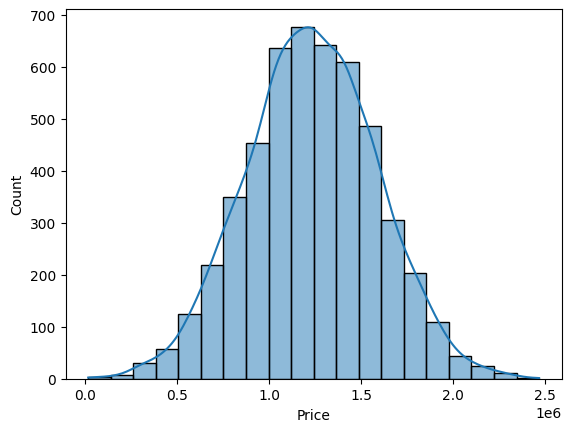

In [ ]:
sns.histplot(x='Price',kde=True,bins=20,data=df)

### Shows how income affects house price.

In [ ]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Area Population', 'Price'],
      dtype='object')

<Axes: xlabel='Avg. Area Income', ylabel='Price'>

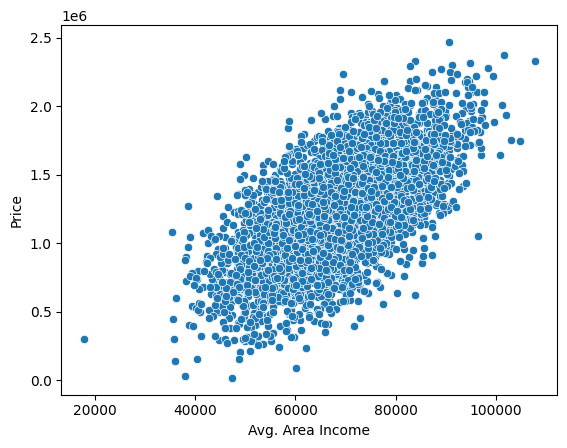

In [ ]:
sns.scatterplot(x='Avg. Area Income',y='Price',data=df)

### Checks whether older houses are cheaper or not.

<Axes: xlabel='Avg. Area House Age', ylabel='Price'>

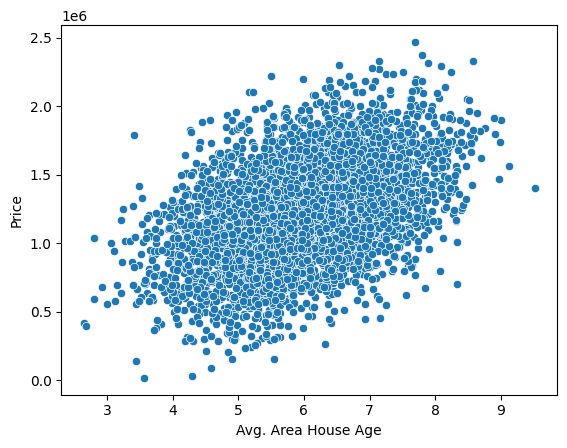

In [ ]:
sns.scatterplot(x='Avg. Area House Age',y='Price',data=df)

In [ ]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Area Population', 'Price'],
      dtype='object')

### Shows how the number of rooms impacts price.

<Axes: xlabel='Avg. Area Number of Rooms', ylabel='Price'>

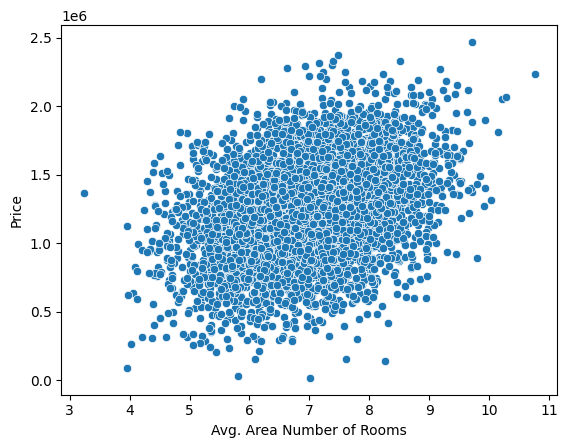

In [ ]:
sns.scatterplot(x='Avg. Area Number of Rooms',y='Price',data=df)

### Gives a quick overall relationship between numeric columns.

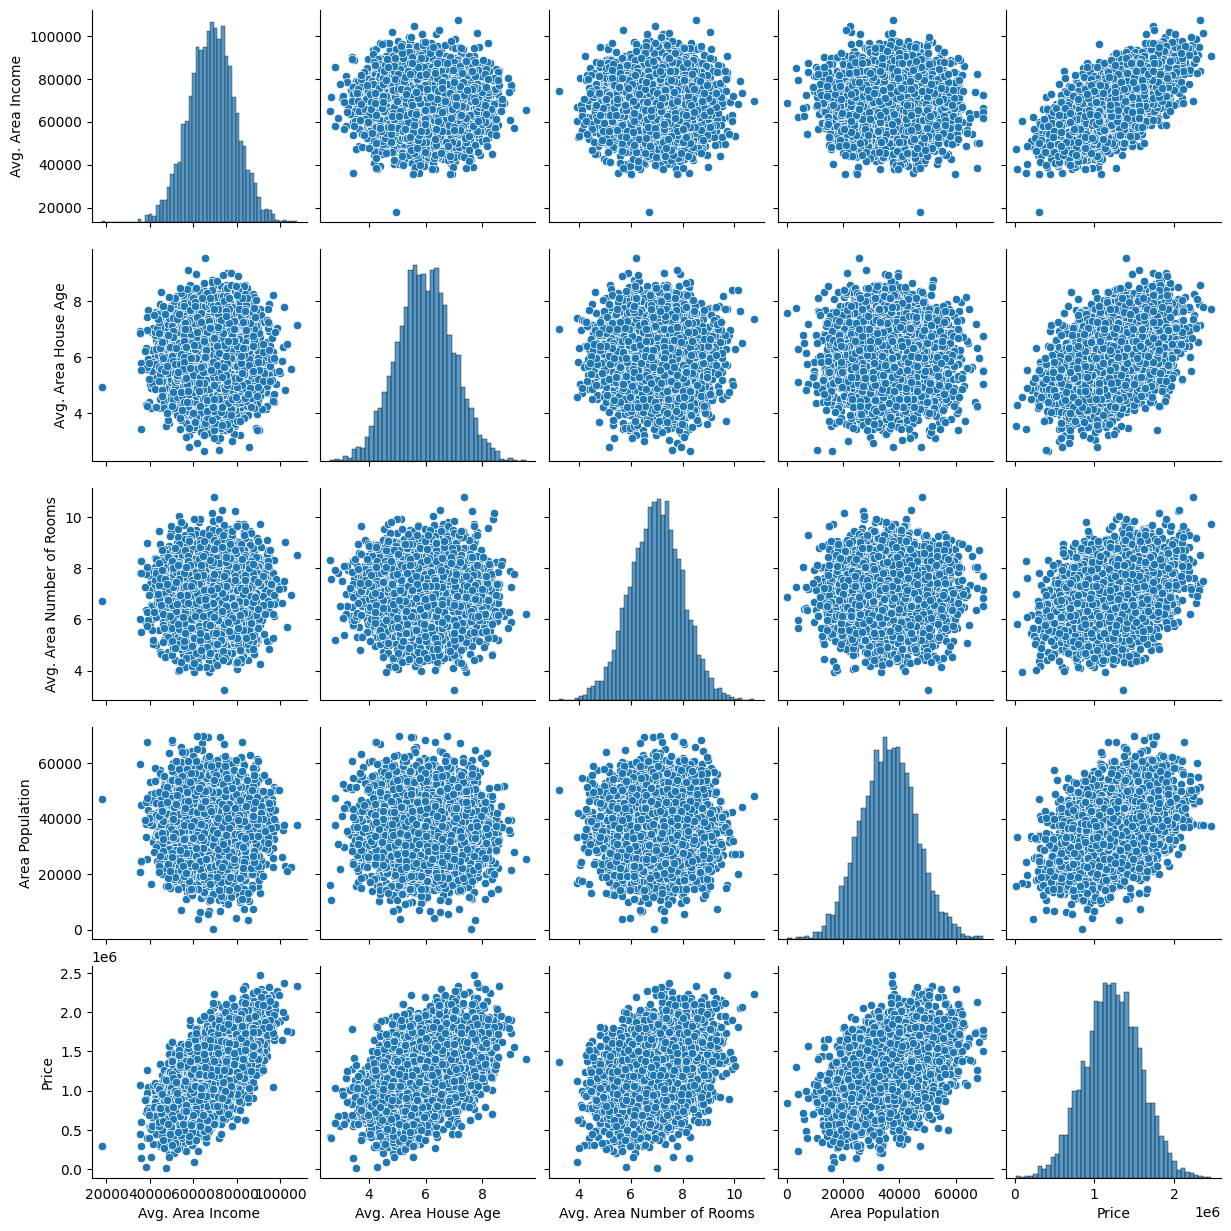

In [ ]:
sns.pairplot(df)

<Axes: >

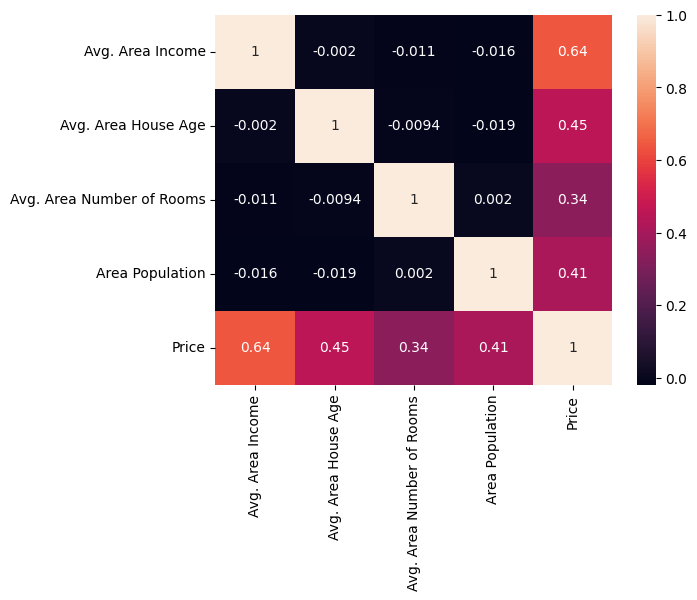

In [ ]:
sns.heatmap(df.corr(),annot=True)

### The two columns which are `Address` and `Avg. Area Number of Bedrooms` are of no use so we can remove it from our dataset.

### Now we have to predict the `Price` of the house so this is the time when we split our data into X and y features.

In [ ]:
x=df.drop('Price',axis=1)
y=df['Price']

### We split the data into training and testing sets, with 80% for training and 20% for testing.
### we will import train_test_split from sklearn.model_selection

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

### Create a Decision Tree Regressor `from sklearn.tree` and then train it using your training data (X_train, y_train).

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:
model=DecisionTreeRegressor()
model.fit(x_train,y_train)

DecisionTreeRegressor()

### Use your trained model to predict the target values for the unseen test data (X_test).

### Check how well your model predicts by calculating the R² score from sklearn.metrices — it shows how much of the target’s variation is explained by your model.”

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
r2_score(y_test,y_pred)

0.7366148849493213

In [ ]:
adjusted_r2=1-(1-r2_score(y_test,y_pred))

In [ ]:
adjusted_r2

0.7366148849493213

In [ ]:
train_pred=model.predict(x_train)
test_pred=model.predict(x_test)

In [ ]:
r2_train=r2_score(y_train,train_pred)
r2_test=r2_score(y_test,test_pred)

In [ ]:
print(r2_train)
print(r2_test)

1.0
0.7366148849493213


Let's get some best parameters for our model and let's check what is the accuracy we are getting for our model for this we will use `RandomizedSearchCV` from `sklearn.model_selection`.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [117]:
grid_params={
    'criterion':['squared_error','friedman_mse','absolute_error','poisson'],
    'splitter':['best', 'random'],
    'max_depth':np.arange(1,60,1),
    'min_samples_split':np.arange(1,60,1),
    'min_samples_leaf':np.arange(1,60,1),
    'max_leaf_nodes':np.arange(1,60,1)
}

In [118]:
rand_search=RandomizedSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_distributions=grid_params,
    cv=5,
    n_iter=100,
    scoring='r2',
    n_jobs=-1
)

In [119]:
rand_search.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

RandomizedSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'criterion': ['squared_error',
                                                      'friedman_mse',
                                                      'absolute_error',
                                                      'poisson'],
                                        'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,...
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59]),
                                        'min_samples_split': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59]),
                                        'splitter': ['best', 'random']},
                   scoring='r2')

In [120]:
best_model=rand_search.best_estimator_

In [121]:
pred=rand_search.predict(x_test)

In [122]:
r2_score(y_test,pred)

0.7164613479052206

In [123]:
train_pred=best_model.predict(x_train)
test_pred=best_model.predict(x_test)
r2_train=r2_score(y_train,train_pred)
r2_test=r2_score(y_test,test_pred)

In [124]:
r2_train

0.7878013912829421

In [125]:
r2_test

0.7164613479052206

In [126]:
rand_search.best_score_

np.float64(0.7168239384767126)

In [127]:
import pickle

In [128]:
with open('model.pkl','wb') as f:
    pickle.dump(rand_search,f)